In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df_matches = pd.read_csv('IPL_Matches_2008_2022.csv') 
df_deliveries = pd.read_csv('IPL_Ball_by_Ball_2008_2022.csv')

df_matches.head()

,ID,City,Date,Season,MatchNumber,Team1,Team2,Venue,TossWinner,TossDecision,SuperOver,WinningTeam,WonBy,Margin,method,Player_of_Match,Team1Players,Team2Players,Umpire1,Umpire2
0,1312200,Ahmedabad,2022-05-29,2022,Final,Rajasthan Royals,Gujarat Titans,"Narendra Modi Stadium, Ahmedabad",Rajasthan Royals,bat,N,Gujarat Titans,Wickets,7.0,NaN,HH Pandya,"['YBK Jaiswal', 'JC Buttler', 'SV Samson', 'D ...","['WP Saha', 'Shubman Gill', 'MS Wade', 'HH Pan...",CB Gaffaney,Nitin Menon
1,1312199,Ahmedabad,2022-05-27,2022,Qualifier 2,Royal Challengers Bangalore,Rajasthan Royals,"Narendra Modi Stadium, Ahmedabad",Rajasthan Royals,field,N,Rajasthan Royals,Wickets,7.0,NaN,JC Buttler,"['V Kohli', 'F du Plessis', 'RM Patidar', 'GJ ...","['YBK Jaiswal', 'JC Buttler', 'SV Samson', 'D ...",CB Gaffaney,Nitin Menon
2,1312198,Kolkata,2022-05-25,2022,Eliminator,Royal Challengers Bangalore,Lucknow Super Giants,"Eden Gardens, Kolkata",Lucknow Super Giants,field,N,Royal Challengers Bangalore,Runs,14.0,NaN,RM Patidar,"['V Kohli', 'F du Plessis', 'RM Patidar', 'GJ ...","['Q de Kock', 'KL Rahul', 'M Vohra', 'DJ Hooda...",J Madanagopal,MA Gough
3,1312197,Kolkata,2022-05-24,2022,Qualifier 1,Rajasthan Royals,Gujarat Titans,"Eden Gardens, Kolkata",Gujarat Titans,field,N,Gujarat Titans,Wickets,7.0,NaN,DA Miller,"['YBK Jaiswal', 'JC Buttler', 'SV Samson', 'D ...","['WP Saha', 'Shubman Gill', 'MS Wade', 'HH Pan...",BNJ Oxenford,VK Sharma
4,1304116,Mumbai,2022-05-22,2022,70,Sunrisers Hyderabad,Punjab Kings,"Wankhede Stadium, Mumbai",Sunrisers Hyderabad,bat,N,Punjab Kings,Wickets,5.0,NaN,Harpreet Brar,"['PK Garg', 'Abhishek Sharma', 'RA Tripathi', ...","['JM Bairstow', 'S Dhawan', 'M Shahrukh Khan',...",AK Chaudhary,NA Patwardhan


In [3]:
df_deliveries.shape


(225954, 17)

In [4]:
df_matches.shape

(950, 20)

In [5]:
df_deliveries.info()

<class 'pandas.DataFrame'>
RangeIndex: 225954 entries, 0 to 225953
Data columns (total 17 columns):
 #   Column             Non-Null Count   Dtype
---  ------             --------------   -----
 0   ID                 225954 non-null  int64
 1   innings            225954 non-null  int64
 2   overs              225954 non-null  int64
 3   ballnumber         225954 non-null  int64
 4   batter             225954 non-null  str  
 5   bowler             225954 non-null  str  
 6   non-striker        225954 non-null  str  
 7   extra_type         12049 non-null   str  
 8   batsman_run        225954 non-null  int64
 9   extras_run         225954 non-null  int64
 10  total_run          225954 non-null  int64
 11  non_boundary       225954 non-null  int64
 12  isWicketDelivery   225954 non-null  int64
 13  player_out         11151 non-null   str  
 14  kind               11151 non-null   str  
 15  fielders_involved  7988 non-null    str  
 16  BattingTeam        225954 non-null  str  
dtypes:

In [6]:
df_matches.info()

<class 'pandas.DataFrame'>
RangeIndex: 950 entries, 0 to 949
Data columns (total 20 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ID               950 non-null    int64  
 1   City             899 non-null    str    
 2   Date             950 non-null    str    
 3   Season           950 non-null    str    
 4   MatchNumber      950 non-null    str    
 5   Team1            950 non-null    str    
 6   Team2            950 non-null    str    
 7   Venue            950 non-null    str    
 8   TossWinner       950 non-null    str    
 9   TossDecision     950 non-null    str    
 10  SuperOver        946 non-null    str    
 11  WinningTeam      946 non-null    str    
 12  WonBy            950 non-null    str    
 13  Margin           932 non-null    float64
 14  method           19 non-null     str    
 15  Player_of_Match  946 non-null    str    
 16  Team1Players     950 non-null    str    
 17  Team2Players     950 non-nu

In [7]:
df_matches.isnull().sum()

ID                   0
City                51
Date                 0
Season               0
MatchNumber          0
Team1                0
Team2                0
Venue                0
TossWinner           0
TossDecision         0
SuperOver            4
WinningTeam          4
WonBy                0
Margin              18
method             931
Player_of_Match      4
Team1Players         0
Team2Players         0
Umpire1              0
Umpire2              0
dtype: int64

In [8]:
# drop the method column 
df_matches.drop('method',axis=1,inplace=True)

In [9]:
df_matches[df_matches['WinningTeam'].isnull()]

,ID,City,Date,Season,MatchNumber,Team1,Team2,Venue,TossWinner,TossDecision,SuperOver,WinningTeam,WonBy,Margin,Player_of_Match,Team1Players,Team2Players,Umpire1,Umpire2
205,1178424,Bengaluru,2019-04-30,2019,49,Royal Challengers Bangalore,Rajasthan Royals,M.Chinnaswamy Stadium,Rajasthan Royals,field,NaN,NaN,NoResults,NaN,NaN,"['V Kohli', 'AB de Villiers', 'MP Stoinis', 'H...","['SV Samson', 'LS Livingstone', 'AM Rahane', '...",NJ Llong,UV Gandhe
437,829813,Bangalore,2015-05-17,2015,55,Royal Challengers Bangalore,Delhi Daredevils,M Chinnaswamy Stadium,Royal Challengers Bangalore,field,NaN,NaN,NoResults,NaN,NaN,"['V Kohli', 'CH Gayle', 'AB de Villiers', 'Man...","['Q de Kock', 'SS Iyer', 'JP Duminy', 'Yuvraj ...",HDPK Dharmasena,K Srinivasan
464,829763,Bangalore,2015-04-29,2015,29,Royal Challengers Bangalore,Rajasthan Royals,M Chinnaswamy Stadium,Rajasthan Royals,field,NaN,NaN,NoResults,NaN,NaN,"['CH Gayle', 'V Kohli', 'AB de Villiers', 'Man...","['AM Rahane', 'SR Watson', 'SPD Smith', 'KK Na...",JD Cloete,PG Pathak
708,501265,Delhi,2011-05-21,2011,68,Delhi Daredevils,Pune Warriors,Feroz Shah Kotla,Delhi Daredevils,bat,NaN,NaN,NoResults,NaN,NaN,"['NV Ojha', 'DA Warner', 'MS Wade', 'CA Ingram...","['MK Pandey', 'JP Faulkner', 'SC Ganguly', 'RV...",SS Hazare,RJ Tucker


In [10]:
# changing / replacing names of banglore to bengaluru and same for venue name 

df_matches['City']=df_matches['City'].replace('Bangalore','Bengaluru',inplace=True)

/var/folders/ly/6l78d8rj5q72fr_0knth1jn00000gp/T/ipykernel_23188/2381487978.py:3: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df_matches['City']=df_matches['City'].replace('Bangalore','Bengaluru',inplace=True)


In [11]:
df_matches['Venue']=df_matches['Venue'].replace("M.Chinnaswamy Stadium",'M Chinnaswamy Stadium')

In [12]:
df_matches['City'].unique()

<StringArray>
[     'Ahmedabad',        'Kolkata',         'Mumbai',    'Navi Mumbai',
           'Pune',          'Dubai',        'Sharjah',      'Abu Dhabi',
          'Delhi',        'Chennai',              nan,      'Hyderabad',
  'Visakhapatnam',     'Chandigarh',      'Bengaluru',         'Jaipur',
         'Indore',         'Kanpur',         'Rajkot',         'Raipur',
         'Ranchi',        'Cuttack',     'Dharamsala',          'Kochi',
         'Nagpur',   'Johannesburg',      'Centurion',         'Durban',
   'Bloemfontein', 'Port Elizabeth',      'Kimberley',    'East London',
      'Cape Town']
Length: 33, dtype: str

In [13]:
df_matches['Venue'].unique()

<StringArray>
[                    'Narendra Modi Stadium, Ahmedabad',
                                'Eden Gardens, Kolkata',
                             'Wankhede Stadium, Mumbai',
                            'Brabourne Stadium, Mumbai',
                   'Dr DY Patil Sports Academy, Mumbai',
        'Maharashtra Cricket Association Stadium, Pune',
                  'Dubai International Cricket Stadium',
                              'Sharjah Cricket Stadium',
                     'Zayed Cricket Stadium, Abu Dhabi',
                          'Arun Jaitley Stadium, Delhi',
             'MA Chidambaram Stadium, Chepauk, Chennai',
                                 'Sheikh Zayed Stadium',
                   'Rajiv Gandhi International Stadium',
  'Dr. Y.S. Rajasekhara Reddy ACA-VDCA Cricket Stadium',
                               'MA Chidambaram Stadium',
         'Punjab Cricket Association IS Bindra Stadium',
                                     'Wankhede Stadium',
                 

In [14]:
df_matches[df_matches['City'].isnull()]['Venue'].unique()

<StringArray>
['Dubai International Cricket Stadium', 'Sharjah Cricket Stadium']
Length: 2, dtype: str

In [15]:
df_matches.loc[df_matches['Venue']=='Dubai International Cricket Stadium','City']='Dubai'
df_matches.loc[df_matches['Venue']=='Sharjah Cricket Stadium','City']='Sharjah'

In [16]:
print("missing cities - ",df_matches['City'].isnull().sum())

missing cities -  0


In [17]:
df_merged=df_deliveries.merge(df_matches,on='ID',how='inner')
print("merged shape :",df_merged.shape)

merged shape : (225954, 35)


In [18]:
df_merged.head()

,ID,innings,overs,ballnumber,batter,bowler,non-striker,extra_type,batsman_run,extras_run,...,TossDecision,SuperOver,WinningTeam,WonBy,Margin,Player_of_Match,Team1Players,Team2Players,Umpire1,Umpire2
0,1312200,1,0,1,YBK Jaiswal,Mohammed Shami,JC Buttler,NaN,0,0,...,bat,N,Gujarat Titans,Wickets,7.0,HH Pandya,"['YBK Jaiswal', 'JC Buttler', 'SV Samson', 'D ...","['WP Saha', 'Shubman Gill', 'MS Wade', 'HH Pan...",CB Gaffaney,Nitin Menon
1,1312200,1,0,2,YBK Jaiswal,Mohammed Shami,JC Buttler,legbyes,0,1,...,bat,N,Gujarat Titans,Wickets,7.0,HH Pandya,"['YBK Jaiswal', 'JC Buttler', 'SV Samson', 'D ...","['WP Saha', 'Shubman Gill', 'MS Wade', 'HH Pan...",CB Gaffaney,Nitin Menon
2,1312200,1,0,3,JC Buttler,Mohammed Shami,YBK Jaiswal,NaN,1,0,...,bat,N,Gujarat Titans,Wickets,7.0,HH Pandya,"['YBK Jaiswal', 'JC Buttler', 'SV Samson', 'D ...","['WP Saha', 'Shubman Gill', 'MS Wade', 'HH Pan...",CB Gaffaney,Nitin Menon
3,1312200,1,0,4,YBK Jaiswal,Mohammed Shami,JC Buttler,NaN,0,0,...,bat,N,Gujarat Titans,Wickets,7.0,HH Pandya,"['YBK Jaiswal', 'JC Buttler', 'SV Samson', 'D ...","['WP Saha', 'Shubman Gill', 'MS Wade', 'HH Pan...",CB Gaffaney,Nitin Menon
4,1312200,1,0,5,YBK Jaiswal,Mohammed Shami,JC Buttler,NaN,0,0,...,bat,N,Gujarat Titans,Wickets,7.0,HH Pandya,"['YBK Jaiswal', 'JC Buttler', 'SV Samson', 'D ...","['WP Saha', 'Shubman Gill', 'MS Wade', 'HH Pan...",CB Gaffaney,Nitin Menon


In [19]:
# finding the top batsmen
top_batsmen=df_merged.groupby('batter')['batsman_run'].sum().sort_values(ascending=False)
print("top batsman is :",top_batsmen)

top batsman is : batter
V Kohli           6634
S Dhawan          6244
DA Warner         5883
RG Sharma         5881
SK Raina          5536
                  ... 
C Nanda              0
Akash Deep           0
S Ladda              0
V Pratap Singh       0
S Lamichhane         0
Name: batsman_run, Length: 605, dtype: int64


In [20]:
# finding most motm

most_motms=df_merged['Player_of_Match'].value_counts()
most_motms.head(5)

Player_of_Match
AB de Villiers    6170
CH Gayle          5186
RG Sharma         4412
DA Warner         4329
MS Dhoni          4130
Name: count, dtype: int64

In [21]:
# Run it on the high-level matches dataframe instead
df_matches['Player_of_Match'].value_counts().head(10)

Player_of_Match
AB de Villiers    25
CH Gayle          22
DA Warner         18
RG Sharma         18
MS Dhoni          17
SR Watson         16
YK Pathan         16
V Kohli           14
KA Pollard        14
SK Raina          14
Name: count, dtype: int64

In [22]:
# counting sixes

sixes=df_merged[df_merged['batsman_run']==6]
top_six_hitter=sixes['batter'].value_counts()
top_six_hitter.head()

batter
CH Gayle          359
AB de Villiers    253
RG Sharma         241
MS Dhoni          229
KA Pollard        224
Name: count, dtype: int64

In [28]:
#findind top wicket taker 
wicket=['caught', 'bowled', 'lbw', 'stumped', 'caught and bowled', 'hit wicket']
wickets_df=df_merged[df_merged['kind'].isin(wicket)]
top_bowlers = wickets_df['bowler'].value_counts().head(10)
top_bowlers

bowler
DJ Bravo           183
SL Malinga         170
YS Chahal          166
A Mishra           166
R Ashwin           157
PP Chawla          157
B Kumar            154
SP Narine          152
Harbhajan Singh    150
JJ Bumrah          148
Name: count, dtype: int64

/var/folders/ly/6l78d8rj5q72fr_0knth1jn00000gp/T/ipykernel_23188/318720537.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_six_hitter.head(10).values, y=top_six_hitter.head(10).index, ax=axes[0], palette='coolwarm')
/var/folders/ly/6l78d8rj5q72fr_0knth1jn00000gp/T/ipykernel_23188/318720537.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_bowlers.values, y=top_bowlers.index, ax=axes[1], palette='viridis')


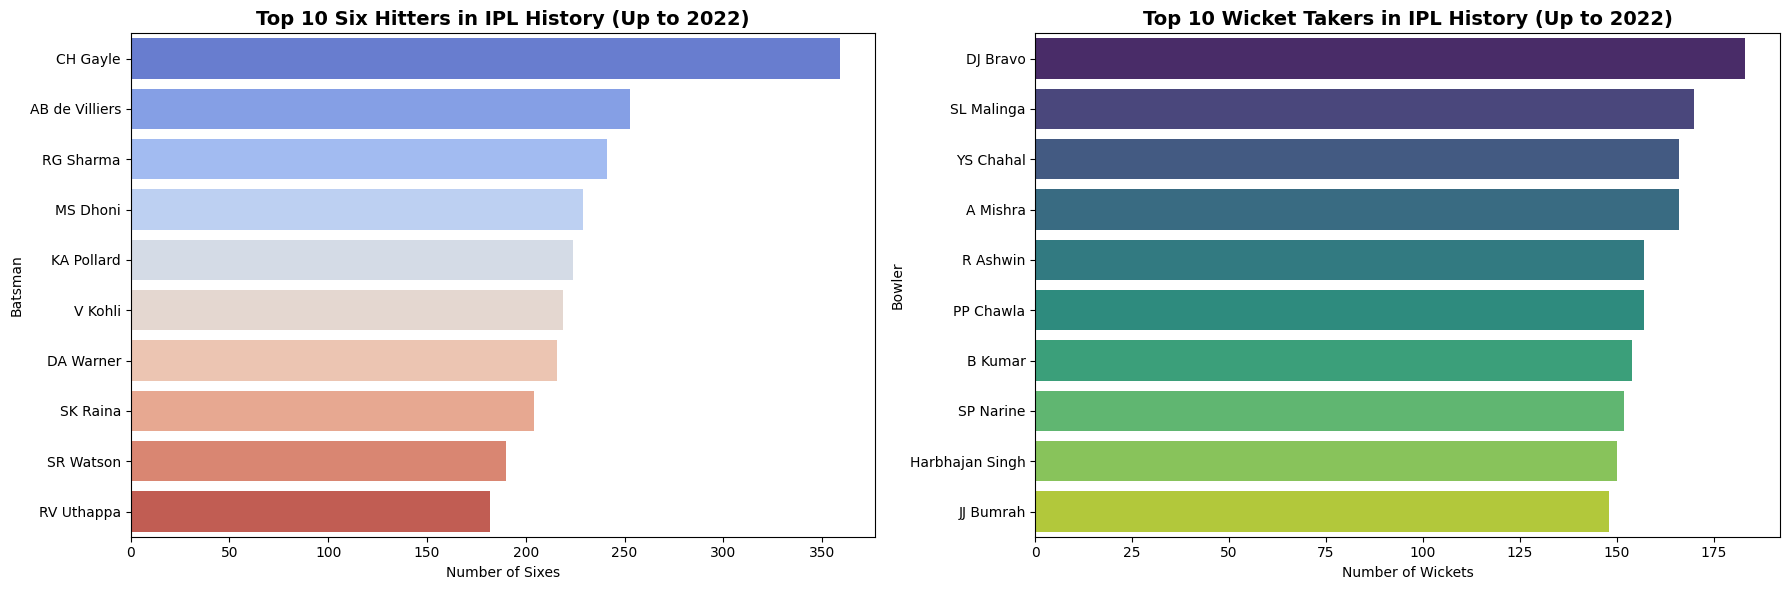

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# CTop 10 Six Hitters
sns.barplot(x=top_six_hitter.head(10).values, y=top_six_hitter.head(10).index, ax=axes[0], palette='coolwarm')
axes[0].set_title('Top 10 Six Hitters in IPL History (Up to 2022)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Number of Sixes')
axes[0].set_ylabel('Batsman')

#  Top 10 Wicket Takers
sns.barplot(x=top_bowlers.values, y=top_bowlers.index, ax=axes[1], palette='viridis')
axes[1].set_title('Top 10 Wicket Takers in IPL History (Up to 2022)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Number of Wickets')
axes[1].set_ylabel('Bowler')
plt.tight_layout()
plt.show()

In [31]:
sixes_df = df_merged[df_merged['batsman_run'] == 6]
print(sixes_df['batter'].value_counts().head(2))

batter
CH Gayle          359
AB de Villiers    253
Name: count, dtype: int64


In [32]:
top_runs = df_merged.groupby('batter')['batsman_run'].sum().sort_values(ascending=False)
top_motm = df_matches['Player_of_Match'].value_counts()

print(top_runs.loc[['V Kohli', 'AB de Villiers']])
print(top_motm.loc[['AB de Villiers', 'V Kohli']])

batter
V Kohli           6634
AB de Villiers    5181
Name: batsman_run, dtype: int64
Player_of_Match
AB de Villiers    25
V Kohli           14
Name: count, dtype: int64


In [33]:
toss_impact = (df_matches['TossWinner'] == df_matches['WinningTeam']).value_counts(normalize=True) * 100
print(toss_impact)

True     51.473684
False    48.526316
Name: proportion, dtype: float64
